# CTR Benchmark — 4 Models (10% Criteo)

| Model | Embedding | Architecture | Loss |
|---|---|---|---|
| M1 | Standard (FeatureHashing) | MLP | BCE |
| M2 | ZeroFLOPS (Head/Mid/Tail) | MLP | BCE |
| M3 | Standard (FeatureHashing) | DCN | BCE |
| M4 | ZeroFLOPS (Head/Mid/Tail) | DCN | BCE |



In [1]:
!pip install datasets -q

In [2]:
import os, time, math, numpy as np, pandas as pd
from collections import defaultdict

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, log_loss
from datasets import load_dataset

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Hyperparameters ───────────────────────────────────────────────────────────
SAMPLE_FRAC    = 0.10          # 10% ~ 4.5M dòng
BATCH_SIZE     = 4096
EPOCHS         = 8
LR             = 1e-3
EMBED_DIM      = 16
MLP_DIMS       = [512, 256, 128]
DROPOUT        = 0.2
NUM_CROSS      = 3             # số lớp Cross trong DCN

# ── ZeroFLOPS thresholds ──────────────────────────────────────────────────────
HEAD_THRESHOLD = 100
MID_THRESHOLD  = 10
HASH_BUCKETS   = 1000

INT_COLS  = [f'I{i}' for i in range(1, 14)]
CAT_COLS  = [f'C{i}' for i in range(1, 27)]
LABEL_COL = 'label'
print('Config loaded ✓')

Device: cuda
GPU: Tesla T4
Config loaded ✓


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# Load data + Preprocessing
# ════════════════════════════════════════════════════════════════════════════
print('Loading dataset...')
ds       = load_dataset('nmpogg/criteo-cleaned', split='train')
n_sample = int(len(ds) * SAMPLE_FRAC)
df       = ds.select(range(n_sample)).to_pandas()
del ds; import gc; gc.collect()
print(f'Loaded {len(df):,} rows')

# Train/Val split 90/10
cut       = int(len(df) * 0.9)
df_train  = df.iloc[:cut].reset_index(drop=True)
df_val    = df.iloc[cut:].reset_index(drop=True)
print(f'Train: {len(df_train):,}  |  Val: {len(df_val):,}')

# ── Integer features: median fill, log1p, z-score ────────────────────────────
medians = df_train[INT_COLS].median()
def proc_int(df_in):
    x = df_in[INT_COLS].fillna(medians).clip(lower=0)
    x = np.log1p(x)
    x = (x - x.mean()) / (x.std() + 1e-8)
    return x.values.astype(np.float32)

int_train = proc_int(df_train)
int_val   = proc_int(df_val)

# ── Labels ────────────────────────────────────────────────────────────────────
y_train = df_train[LABEL_COL].values.astype(np.float32)
y_val   = df_val[LABEL_COL].values.astype(np.float32)
print(f'Label rate: {y_train.mean():.3f}')

# ── Standard: FeatureHashing ─────────────────────────────────────────────────
def feature_hash(series):
    return series.astype(str).apply(lambda x: int(hash(x) % HASH_BUCKETS)).values.astype(np.int64)

cat_std_train = np.stack([feature_hash(df_train[c]) for c in CAT_COLS], axis=1)
cat_std_val   = np.stack([feature_hash(df_val[c])   for c in CAT_COLS], axis=1)
print(f'Standard cat shape: {cat_std_train.shape}')

# ── ZeroFLOPS: Head/Mid/Tail ──────────────────────────────────────────────────
print('Building ZeroFLOPS vocab...')
freq_maps = {c: df_train[c].astype(str).value_counts().to_dict() for c in CAT_COLS}
head_vocab, mid_vocab = {}, {}
head_vocab_sizes, mid_vocab_sizes = {}, {}
for c in CAT_COLS:
    hv = {v: i+1 for i,(v,cnt) in enumerate((x for x in freq_maps[c].items() if x[1] >= HEAD_THRESHOLD))}
    mv = {v: i+1 for i,(v,cnt) in enumerate((x for x in freq_maps[c].items() if MID_THRESHOLD <= x[1] < HEAD_THRESHOLD))}
    head_vocab[c], mid_vocab[c] = hv, mv
    head_vocab_sizes[c] = len(hv) + 1
    mid_vocab_sizes[c]  = len(mv) + 1

def encode_zf(df_in):
    n = len(df_in)
    H = np.zeros((n, len(CAT_COLS)), dtype=np.int64)
    M = np.zeros((n, len(CAT_COLS)), dtype=np.int64)
    T = np.zeros((n, len(CAT_COLS)), dtype=np.int64)
    for i, c in enumerate(CAT_COLS):
        s   = df_in[c].astype(str)
        cnt = s.map(freq_maps[c]).fillna(0).astype(int)
        H[:, i] = np.where(cnt >= HEAD_THRESHOLD, s.map(head_vocab[c]).fillna(0).astype(int), 0)
        M[:, i] = np.where((cnt >= MID_THRESHOLD) & (cnt < HEAD_THRESHOLD),
                            s.map(mid_vocab[c]).fillna(0).astype(int), 0)
        T[:, i] = np.where(cnt < MID_THRESHOLD,
                            s.apply(lambda x: int(hash(x) % HASH_BUCKETS)), 0)
    return H, M, T

print('Encoding ZeroFLOPS train...')
t0 = time.time()
head_train, mid_train, tail_train = encode_zf(df_train)
print(f'  Done {time.time()-t0:.1f}s')

print('Encoding ZeroFLOPS val...')
t0 = time.time()
head_val, mid_val, tail_val = encode_zf(df_val)
print(f'  Done {time.time()-t0:.1f}s')

Loading dataset...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

data/train-00000-of-00050.parquet:   0%|          | 0.00/67.7M [00:00<?, ?B/s]

...

data/train-00048-of-00050.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00049-of-00050.parquet:   0%|          | 0.00/73.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45840617 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Loaded 4,584,061 rows
Train: 4,125,654  |  Val: 458,407
Label rate: 0.251
Standard cat shape: (4125654, 26)
Building ZeroFLOPS vocab...
Encoding ZeroFLOPS train...
  Done 80.5s
Encoding ZeroFLOPS val...
  Done 11.0s


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# PyTorch Datasets & DataLoaders
# ════════════════════════════════════════════════════════════════════════════
class StdDataset(Dataset):
    def __init__(self, int_f, cat_f, y):
        self.int_f = torch.tensor(int_f, dtype=torch.float32)
        self.cat_f = torch.tensor(cat_f, dtype=torch.long)
        self.y     = torch.tensor(y,     dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.int_f[i], self.cat_f[i], self.y[i]

class ZFDataset(Dataset):
    def __init__(self, int_f, H, M, T, y):
        self.int_f = torch.tensor(int_f, dtype=torch.float32)
        self.H = torch.tensor(H, dtype=torch.long)
        self.M = torch.tensor(M, dtype=torch.long)
        self.T = torch.tensor(T, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.int_f[i], self.H[i], self.M[i], self.T[i], self.y[i]

kw = dict(num_workers=2, pin_memory=True)
train_std_loader = DataLoader(StdDataset(int_train, cat_std_train, y_train),
                               BATCH_SIZE, shuffle=True,  **kw)
val_std_loader   = DataLoader(StdDataset(int_val,   cat_std_val,   y_val),
                               BATCH_SIZE, shuffle=False, **kw)
train_zf_loader  = DataLoader(ZFDataset(int_train, head_train, mid_train, tail_train, y_train),
                               BATCH_SIZE, shuffle=True,  **kw)
val_zf_loader    = DataLoader(ZFDataset(int_val,   head_val,   mid_val,   tail_val,   y_val),
                               BATCH_SIZE, shuffle=False, **kw)
print(f'Train batches (std): {len(train_std_loader)}')
print(f'Train batches (zf):  {len(train_zf_loader)}')

Train batches (std): 1008
Train batches (zf):  1008


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# Building blocks
# ════════════════════════════════════════════════════════════════════════════
def build_mlp(in_dim, dims, drop):
    layers, d = [], in_dim
    for h in dims:
        layers += [nn.Linear(d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(drop)]
        d = h
    layers.append(nn.Linear(d, 1))
    return nn.Sequential(*layers)

class CrossNet(nn.Module):
    """Cross Network: x_(l+1) = x0 * (xl^T * w) + b + xl"""
    def __init__(self, dim, n_layers):
        super().__init__()
        self.w = nn.ParameterList([nn.Parameter(torch.randn(dim,1)*0.01) for _ in range(n_layers)])
        self.b = nn.ParameterList([nn.Parameter(torch.zeros(dim))        for _ in range(n_layers)])
    def forward(self, x):
        x0 = x
        for w, b in zip(self.w, self.b):
            x = x0 * (x @ w) + b + x
        return x


# ── Embedding helpers ─────────────────────────────────────────────────────────
class StdEmbedding(nn.Module):
    """FeatureHashing → 1 shared Embedding table"""
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(HASH_BUCKETS, EMBED_DIM, padding_idx=0)
    def forward(self, cat_x):
        return self.emb(cat_x).view(cat_x.size(0), -1)  # (B, 26*EMBED_DIM)

class ZFEmbedding(nn.Module):
    """Head/Mid/Tail → 3 tables per col → element-wise ADD"""
    def __init__(self):
        super().__init__()
        self.head_embs = nn.ModuleList([
            nn.Embedding(head_vocab_sizes[c], EMBED_DIM, padding_idx=0) for c in CAT_COLS])
        self.mid_embs  = nn.ModuleList([
            nn.Embedding(mid_vocab_sizes[c],  EMBED_DIM, padding_idx=0) for c in CAT_COLS])
        self.tail_emb  = nn.Embedding(HASH_BUCKETS, EMBED_DIM, padding_idx=0)
    def forward(self, H, M, T):
        embs = [self.head_embs[i](H[:,i]) + self.mid_embs[i](M[:,i]) + self.tail_emb(T[:,i])
                for i in range(len(CAT_COLS))]
        return torch.stack(embs, dim=1).view(H.size(0), -1)  # (B, 26*EMBED_DIM)


# ════════════════════════════════════════════════════════════════════════════
# M1: Standard Embedding + MLP
# ════════════════════════════════════════════════════════════════════════════
class M1_StdMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = StdEmbedding()
        self.mlp = build_mlp(EMBED_DIM*len(CAT_COLS) + len(INT_COLS), MLP_DIMS, DROPOUT)
    def forward(self, int_x, cat_x):
        return self.mlp(torch.cat([self.emb(cat_x), int_x], dim=1)).squeeze(-1)

# ════════════════════════════════════════════════════════════════════════════
# M2: ZeroFLOPS Embedding + MLP
# ════════════════════════════════════════════════════════════════════════════
class M2_ZFMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = ZFEmbedding()
        self.mlp = build_mlp(EMBED_DIM*len(CAT_COLS) + len(INT_COLS), MLP_DIMS, DROPOUT)
    def forward(self, int_x, H, M, T):
        return self.mlp(torch.cat([self.emb(H,M,T), int_x], dim=1)).squeeze(-1)

# ════════════════════════════════════════════════════════════════════════════
# M3: Standard Embedding + DCN
# ════════════════════════════════════════════════════════════════════════════
class M3_StdDCN(nn.Module):
    def __init__(self):
        super().__init__()
        in_dim = EMBED_DIM*len(CAT_COLS) + len(INT_COLS)
        self.emb   = StdEmbedding()
        self.cross = CrossNet(in_dim, NUM_CROSS)
        self.deep  = build_mlp(in_dim, MLP_DIMS, DROPOUT)  # returns (B,1) via last Linear
        # output: cross(in_dim) + deep_last_hidden → 1
        # Nhưng build_mlp đã có Linear cuối → tách riêng
        self.deep_layers = nn.Sequential(*list(build_mlp(in_dim, MLP_DIMS, DROPOUT).children())[:-1])
        self.out   = nn.Linear(in_dim + MLP_DIMS[-1], 1)
    def forward(self, int_x, cat_x):
        x     = torch.cat([self.emb(cat_x), int_x], dim=1)
        cross = self.cross(x)
        deep  = self.deep_layers(x)
        return self.out(torch.cat([cross, deep], dim=1)).squeeze(-1)

# ════════════════════════════════════════════════════════════════════════════
# M4: ZeroFLOPS Embedding + DCN
# ════════════════════════════════════════════════════════════════════════════
class M4_ZFDCN(nn.Module):
    def __init__(self):
        super().__init__()
        in_dim = EMBED_DIM*len(CAT_COLS) + len(INT_COLS)
        self.emb   = ZFEmbedding()
        self.cross = CrossNet(in_dim, NUM_CROSS)
        self.deep_layers = nn.Sequential(*list(build_mlp(in_dim, MLP_DIMS, DROPOUT).children())[:-1])
        self.out   = nn.Linear(in_dim + MLP_DIMS[-1], 1)
    def forward(self, int_x, H, M, T):
        x     = torch.cat([self.emb(H,M,T), int_x], dim=1)
        cross = self.cross(x)
        deep  = self.deep_layers(x)
        return self.out(torch.cat([cross, deep], dim=1)).squeeze(-1)


# ── Khởi tạo ─────────────────────────────────────────────────────────────────
m1 = M1_StdMLP().to(DEVICE)
m2 = M2_ZFMLP().to(DEVICE)
m3 = M3_StdDCN().to(DEVICE)
m4 = M4_ZFDCN().to(DEVICE)

print(f'M1 Std+MLP:  {sum(p.numel() for p in m1.parameters()):>12,} params')
print(f'M2 ZF+MLP:   {sum(p.numel() for p in m2.parameters()):>12,} params')
print(f'M3 Std+DCN:  {sum(p.numel() for p in m3.parameters()):>12,} params')
print(f'M4 ZF+DCN:   {sum(p.numel() for p in m4.parameters()):>12,} params')

M1 Std+MLP:       402,305 params
M2 ZF+MLP:      3,349,169 params
M3 Std+DCN:       791,613 params
M4 ZF+DCN:      3,352,172 params


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# Training & Evaluation
# ════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, opt, crit, is_zf=False):
    model.train()
    total = 0
    for batch in loader:
        if is_zf:
            int_x, H, M, T, y = [b.to(DEVICE) for b in batch]
            pred = model(int_x, H, M, T)
        else:
            int_x, cat_x, y = [b.to(DEVICE) for b in batch]
            pred = model(int_x, cat_x)
        opt.zero_grad()
        loss = crit(pred, y)
        loss.backward(); opt.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def evaluate(model, loader, is_zf=False):
    model.eval()
    preds, labels = [], []
    for batch in loader:
        if is_zf:
            int_x, H, M, T, y = batch
            p = torch.sigmoid(model(int_x.to(DEVICE), H.to(DEVICE),
                                    M.to(DEVICE), T.to(DEVICE))).cpu().numpy()
        else:
            int_x, cat_x, y = batch
            p = torch.sigmoid(model(int_x.to(DEVICE), cat_x.to(DEVICE))).cpu().numpy()
        preds.append(p); labels.append(y.numpy())
    p = np.concatenate(preds); l = np.concatenate(labels)
    return roc_auc_score(l, p), log_loss(l, p)

def run(name, model, train_loader, val_loader, is_zf=False):
    print(f'\n{"="*60}\nTraining {name}\n{"="*60}')
    crit  = nn.BCEWithLogitsLoss()
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=1, gamma=0.5)
    hist  = []
    for ep in range(1, EPOCHS+1):
        t0      = time.time()
        tr_loss = train_epoch(model, train_loader, opt, crit, is_zf)
        auc, ll = evaluate(model, val_loader, is_zf)
        sched.step()
        hist.append(dict(epoch=ep, loss=tr_loss, auc=auc, logloss=ll))
        print(f'[{ep}/{EPOCHS}] loss={tr_loss:.4f}  AUC={auc:.4f}  LogLoss={ll:.4f}  {time.time()-t0:.0f}s')
        torch.save({'epoch':ep,'model':model.state_dict(),'auc':auc,'ll':ll},
                   f'ckpt_{name.replace(" ","_")}_ep{ep}.pt')
    return hist

import gc

h1 = run('M1_Std+MLP', m1, train_std_loader, val_std_loader, is_zf=False)
gc.collect(); torch.cuda.empty_cache()

h2 = run('M2_ZF+MLP',  m2, train_zf_loader,  val_zf_loader,  is_zf=True)
gc.collect(); torch.cuda.empty_cache()

h3 = run('M3_Std+DCN', m3, train_std_loader, val_std_loader, is_zf=False)
gc.collect(); torch.cuda.empty_cache()

h4 = run('M4_ZF+DCN',  m4, train_zf_loader,  val_zf_loader,  is_zf=True)
gc.collect(); torch.cuda.empty_cache()


Training M1_Std+MLP
[1/8] loss=0.4820  AUC=0.7672  LogLoss=0.4703  38s
[2/8] loss=0.4687  AUC=0.7736  LogLoss=0.4654  39s
[3/8] loss=0.4639  AUC=0.7764  LogLoss=0.4632  42s
[4/8] loss=0.4609  AUC=0.7778  LogLoss=0.4622  39s
[5/8] loss=0.4592  AUC=0.7786  LogLoss=0.4616  40s
[6/8] loss=0.4584  AUC=0.7788  LogLoss=0.4615  38s
[7/8] loss=0.4578  AUC=0.7789  LogLoss=0.4614  38s
[8/8] loss=0.4577  AUC=0.7790  LogLoss=0.4613  38s

Training M2_ZF+MLP
[1/8] loss=0.4794  AUC=0.7738  LogLoss=0.4655  69s
[2/8] loss=0.4620  AUC=0.7809  LogLoss=0.4601  72s
[3/8] loss=0.4560  AUC=0.7837  LogLoss=0.4579  71s
[4/8] loss=0.4527  AUC=0.7847  LogLoss=0.4571  73s
[5/8] loss=0.4509  AUC=0.7854  LogLoss=0.4565  75s
[6/8] loss=0.4499  AUC=0.7856  LogLoss=0.4565  70s
[7/8] loss=0.4494  AUC=0.7857  LogLoss=0.4564  71s
[8/8] loss=0.4492  AUC=0.7858  LogLoss=0.4564  72s

Training M3_Std+DCN
[1/8] loss=0.4800  AUC=0.7673  LogLoss=0.4706  39s
[2/8] loss=0.4671  AUC=0.7740  LogLoss=0.4650  41s
[3/8] loss=0.4621  A


FINAL RESULTS  (10% Criteo, EMBED_DIM=16, BCE, 8 epochs)
Model               AUC    LogLoss       Params
----------------------------------------------
M1 Std+MLP       0.7790     0.4613      402,305
M2 ZF+MLP        0.7858     0.4564    3,349,169
M3 Std+DCN       0.7792     0.4612      791,613
M4 ZF+DCN        0.7861     0.4560    3,352,172


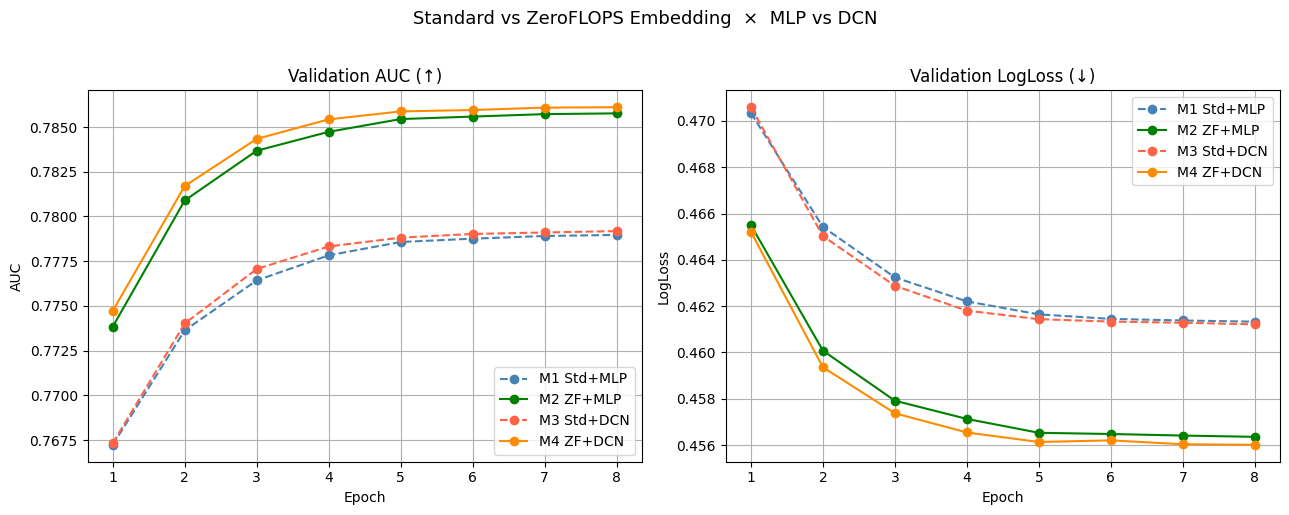


Saved benchmark_4models.png

--- Embedding effect (MLP backbone) ---
ZF vs Std (MLP):  ΔAUC = +0.0068
ZF vs Std (DCN):  ΔAUC = +0.0069

--- Architecture effect (same embedding) ---
DCN vs MLP (Std): ΔAUC = +0.0002
DCN vs MLP (ZF):  ΔAUC = +0.0003


In [7]:
import matplotlib.pyplot as plt, pandas as pd

results = [
    ('M1 Std+MLP',  h1, m1, 'steelblue',  '--'),
    ('M2 ZF+MLP',   h2, m2, 'green',      '-'),
    ('M3 Std+DCN',  h3, m3, 'tomato',     '--'),
    ('M4 ZF+DCN',   h4, m4, 'darkorange', '-'),
]

print('\n' + '='*62)
print('FINAL RESULTS  (10% Criteo, EMBED_DIM=16, BCE, 8 epochs)')
print('='*62)
print(f"{'Model':<14} {'AUC':>8} {'LogLoss':>10} {'Params':>12}")
print('-'*46)
for name, h, model, *_ in results:
    df = pd.DataFrame(h)
    p  = sum(x.numel() for x in model.parameters())
    print(f"{name:<14} {df['auc'].iloc[-1]:>8.4f} {df['logloss'].iloc[-1]:>10.4f} {p:>12,}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, h, model, color, ls in results:
    df = pd.DataFrame(h)
    axes[0].plot(df['epoch'], df['auc'],     color=color, ls=ls, marker='o', label=name)
    axes[1].plot(df['epoch'], df['logloss'], color=color, ls=ls, marker='o', label=name)
for ax, title, yl in zip(axes,
    ['Validation AUC (↑)', 'Validation LogLoss (↓)'], ['AUC','LogLoss']):
    ax.set(xlabel='Epoch', ylabel=yl, title=title)
    ax.legend(); ax.grid(True)
plt.suptitle('Standard vs ZeroFLOPS Embedding  ×  MLP vs DCN', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('benchmark_4models.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved benchmark_4models.png')

# So sánh theo từng trục
print('\n--- Embedding effect (MLP backbone) ---')
d = pd.DataFrame(h2)['auc'].iloc[-1] - pd.DataFrame(h1)['auc'].iloc[-1]
print(f'ZF vs Std (MLP):  ΔAUC = {d:+.4f}')
d = pd.DataFrame(h4)['auc'].iloc[-1] - pd.DataFrame(h3)['auc'].iloc[-1]
print(f'ZF vs Std (DCN):  ΔAUC = {d:+.4f}')

print('\n--- Architecture effect (same embedding) ---')
d = pd.DataFrame(h3)['auc'].iloc[-1] - pd.DataFrame(h1)['auc'].iloc[-1]
print(f'DCN vs MLP (Std): ΔAUC = {d:+.4f}')
d = pd.DataFrame(h4)['auc'].iloc[-1] - pd.DataFrame(h2)['auc'].iloc[-1]
print(f'DCN vs MLP (ZF):  ΔAUC = {d:+.4f}')

In [8]:
for name, model in [('m1_std_mlp',m1),('m2_zf_mlp',m2),('m3_std_dcn',m3),('m4_zf_dcn',m4)]:
    torch.save(model.state_dict(), f'{name}_final.pt')
print('All 4 models saved ✓')

All 4 models saved ✓
